Text Data Cleaning & Preprocessing:

In [1]:
!pip install emoji

In [2]:
#import necessary libraries
import pandas as pd
import numpy as np

# for regular expression,emojis & tokenization
import re

#for removing punctuation
import string

#for spelling correction 
from textblob import TextBlob

#for  stopwords
import nltk
from nltk.corpus import stopwords

#for replace emojis
import emoji

#for tokenization
from nltk.tokenize import word_tokenize,sent_tokenize

#for tokenization
# import spacy

#for stemming
from nltk.stem.porter import PorterStemmer

#for lemmatization
from nltk.stem import WordNetLemmatizer

In [3]:
#import data
df=pd.read_csv(r'C:\Users\123\Desktop\IMDB Dataset.csv')

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Data Cleaning:

In [5]:
#total rows & columns of the data
df.shape

(50000, 2)

In [6]:
# basic information about data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
#checking unique categories of data
df.sentiment.unique()

array(['positive', 'negative'], dtype=object)

In [8]:
# total null values
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [9]:
# total duplicate values
df.duplicated().sum()

np.int64(418)

In [10]:
# removing duplicates
df.drop_duplicates(inplace=True)


In [12]:
# checking duplicates again
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(49582, 2)

<Axes: ylabel='count'>

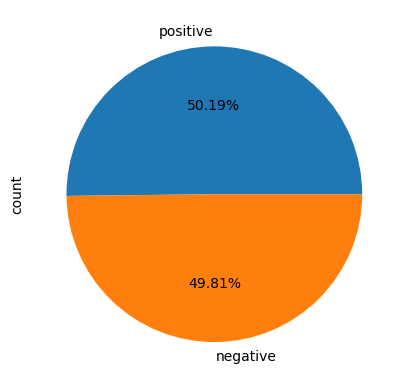

In [14]:
df['sentiment'].value_counts().plot(kind='pie',autopct='%1.2f%%')

Data Preprocessing:

1.Conversion of Data to Lower Case:

In [15]:
df['review']=df['review'].str.lower()

In [16]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


2.Removing html Tags:

In [18]:
#function for remove html tags
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub(r'',text)

In [19]:
# test on example
text='<html><body><p> Movie 1</p><p> Actor-Aamir Khan</p></p> Click here to <a href https.www.com>Download'
remove_html_tags(text)

' Movie 1 Actor-Aamir Khan Click here to Download'

In [20]:
#apply on Dataset
df['review']=df['review'].apply(remove_html_tags)

In [21]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


3.Remove URLs

In [22]:
# remove url's from text
def remove_url(text):
    url=re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'',text)

In [23]:
# example test
text = 'Battery Life One of the standout features is the impressive battery life https://.www.com man '
remove_url(text)

'Battery Life One of the standout features is the impressive battery life  man '

In [24]:
#apply on dataset
df['review']=df['review'].apply(remove_url)

In [25]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


4.Remove Punctuation:

In [26]:
# calling punctuation method from string
exclude = string.punctuation
print(exclude)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [27]:
#removing punctuations
def remove_punc(text):
    return text.translate(str.maketrans('','',exclude))

In [28]:
# example test
text = 'Hello, how/ are you?'
remove_punc(text)

'Hello how are you'

In [29]:
#apply on Datasets
df['review']=df['review'].apply(remove_punc)

In [30]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive


5.Remove Chatwords:

In [34]:
# dictionary for chatwords
chatwords = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "LOL": "Laughing out loud",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don’t care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "IDC": "I don’t care",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "LMAO": "Laughing my a** off",
    "BFF": "Best friends forever",
    "CSL": "Can’t stop laughing"
}

In [35]:
# function for remove chatwords
def chat_conversation(text):
    new_text=[]
    for word in text.split():
        if word.upper() in chatwords:
            new_text.append(chatwords[word.upper()])
        else:
            new_text.append(word)
    return ' '.join(new_text)       

In [36]:
#example test
chat_conversation('IMHO he is the best')

'In My Honest/Humble Opinion he is the best'

In [37]:
#apply on dataset
df['review']=df['review'].apply(chat_conversation)

In [38]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend Te...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the Tears in my eyes of...,positive


6.Spelling Correction:

In [ ]:
# function for spelling correction
def spell_correction(text):
    text_correct=TextBlob(text)
    return text_correct.correct().string

In [ ]:
#example test
text='certain conditionas durringg severl generationns aree modefid in the same maner'
spell_correction(text)

In [ ]:
#apply on dataset
df['review']=df['review'].apply(spell_correction)

In [ ]:
df.head()

In [ ]:
print('hj')

7.Removing Stopword:

In [ ]:
#download stopwords 
nltk.download('stopwords')

In [ ]:
#english stopwords list
stopwords.words('english')

In [ ]:
#remove stopwords functions
def remove_stopwords(text):
    new_text=[]
    for word in text.split():
        if word.lower() in stopwords.words('english'):
            new_text.append('')
        else:
            new_text.append(word)
    x=new_text[:]
    new_text.clear()
    return ' '.join(x)

In [ ]:
#examplw test
remove_stopwords('probably my all-time favourite movie, a story of selflessness,sacrifice dedication noble cause')


In [ ]:
#apply on dataset
df['review']=df['review'].apply(remove_stopwords)

In [ ]:
df.head()

8.Handling Emojis:

In [ ]:
# funvtion foer remove emojis
def remove_emojis(text):
    emoji_pattern=re.compile(
        "["
        "\U0001F600-\U0001F64F" # emotions
        "\U0001F300-\U0001F5FF" # symbols & pictographs
        "\U0001F680-\U0001F6FF" # transport & map symbols
        "\U0001F1E0-\U0001F1FF" # flags (ios)
        "\U00002702-\U000027B0" # Dingbats
        "\U000024C2-\U0001F251" # Enclosed CJK Letters and Months
        "]+" , flags=re.UNICODE)
    return emoji_pattern.sub(r'',text)

In [ ]:
# example test
remove_emojis('Hello😘 World💖 !This is fun🎉')

In [ ]:
#functions for replace emojis
def replace_emojis(text):
    return emoji.demojize(text)

In [ ]:
#example test
replace_emojis('👍 Python ✔ is 😜 ')

In [ ]:
#applu data
df['review']=df['review'].apply(replace_emojis)

In [ ]:
df.head()

9.Tokenization

1.Use python split function directly to tokenize the data

In [ ]:
#word tokenize 
sent='I am Pakistani.I Love my Country'
sent.split()

In [ ]:
#sentence Tokenize
sent='I am Pakistani.I Love my Country'
sent.split('.')

2.Regular Expression for Tokenizetion

In [ ]:
sent='The car is going 10km faster'
tokens=re.findall('[\W]+',sent)
tokens

3.Using nltk Library:

In [ ]:
nltk.download('punkt_tab')

In [ ]:
sent='The car is going 10km faster'
tokens=word_tokenize(sent)
tokens

In [ ]:
sent='The car is going 10km faster'
tokens=sent_tokenize(sent)
tokens

4.Using Spacy Library

In [18]:
!pip install spacy

  Using cached spacy-3.8.7-cp313-cp313-win_amd64.whl.metadata (28 kB)
Using cached spacy-3.8.7-cp313-cp313-win_amd64.whl (13.9 MB)


In [ ]:
import spacy

In [ ]:
tokens=spacy.load('en_core_web_sm')

In [ ]:
sent='The car is going 10km faster'

In [ ]:
tokens=tokens(sent)

In [ ]:
for token in tokens:
    print(token)

In [ ]:
import nltk

In [ ]:
from nltk.tokenize import word_tokenize,sent_tokenize

In [ ]:
#function for tokenization
def tokenization(text):
    word_token=word_tokenize(text)
    return word_token

In [ ]:
tokenization('The car is going 10km faster')

In [ ]:
#apply on dataset by nltk tokenizer
df['review']=df['review'].apply(tokenization)

In [ ]:
df.head()

10.Stemming & Lemmatization:

In [ ]:
# object of porter stemmer
ps=PorterStemmer()

In [ ]:
# function for stemming
def stem_words(text):
    return [ps.stem(word) for word in text]

In [ ]:
sample=['walk','walks','walking','walked']
stem_words(sample)

In [ ]:
df['review']=df['review'].apply(stem_words)

In [ ]:
df.head()

In [ ]:
df['review'][0]

Note: the stemmed word is not always a valid word , it just chops of the end of words to get
the root form , doesn't care about meaning or grammer.

Lemmatization coverts a word to its base (dictionary) form using vocabulary and grammar rules.

Wordnet Lemmatization:

In [73]:
#download wordnet
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to C:\Users\123/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
#initialize object
lemmatizer=WordNetLemmatizer()

In [ ]:
# function for lemmatizer
def lemmatize_text(text):
    lemmatized_tokens=[lemmatizer.lemmatize(token) for token in text]
    return lemmatized_tokens

In [ ]:
#example test
sent=['study','studies','studying','studied']
lemmatize_text(sent)

In [ ]:
#apply on data 
df['review']=df['review'].apply(lemmatize_text)

In [ ]:
df.head()

In [ ]:
df.review[0]